In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    r2_score, mean_absolute_error, mean_squared_error
)

In [2]:
# VERİ SETİNİN YÜKLENMESİ 
dosya_yolu = r"C:\Users\omer\Desktop\arac_fiyat_tahmin_veri_seti_v1.csv"
veri = pd.read_csv(dosya_yolu)

In [3]:
# AYKIRI DEĞERLERİN TEMİZLENMESİ (0.04 - 0.999) 
alt_limit = veri['fiyat'].quantile(0.04)
ust_limit = veri['fiyat'].quantile(0.999)

print(f"Eski Veri Boyutu: {len(veri)}")
veri = veri[(veri['fiyat'] >= alt_limit) & (veri['fiyat'] <= ust_limit)]
print(f"Yeni Veri Boyutu: {len(veri)}")
print(f"Fiyat Aralığı: {alt_limit:,.0f} TL - {ust_limit:,.0f} TL\n")

Eski Veri Boyutu: 50380
Yeni Veri Boyutu: 48386
Fiyat Aralığı: 170,000 TL - 7,043,470 TL



In [4]:
# ÖN İŞLEME 
if 'marka' in veri.columns:
    veri = veri.drop(columns=['marka', 'seri', 'model'])

# Hedef Değişkenler
veri['fiyat_kategorisi'] = pd.qcut(veri['fiyat'], q=4, labels=['Düşük', 'Orta', 'Yüksek', 'Lüks'])
X = veri.drop(columns=['fiyat', 'fiyat_kategorisi'])
y_reg = veri['fiyat']
y_cls = veri['fiyat_kategorisi']

# Veri Bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_cls, y_test_cls = train_test_split(X, y_cls, test_size=0.2, random_state=42)

In [7]:
# REGRESYON ANALİZİ (Decision Tree) 
print(" DECISION TREE REGRESYON PERFORMANSI ")
# n_estimators yerine ağaç derinliği (max_depth) önemlidir
dt_reg = DecisionTreeRegressor(max_depth=20, random_state=42)

# 10-Katlı Çapraz Doğrulama
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(dt_reg, X, y_reg, cv=kf, scoring=['r2', 'neg_mean_absolute_error'])

dt_reg.fit(X_train, y_train_reg)
y_pred_reg = dt_reg.predict(X_test)

print(f"CV R2 Ortalaması: %{cv_results['test_r2'].mean()*100:.2f}")
print(f"Test R2 Skoru: %{r2_score(y_test_reg, y_pred_reg)*100:.2f}")
print(f"Test MAE: {mean_absolute_error(y_test_reg, y_pred_reg):,.2f} TL")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):,.2f} TL\n")

 DECISION TREE REGRESYON PERFORMANSI 
CV R2 Ortalaması: %92.86
Test R2 Skoru: %92.66
Test MAE: 86,323.56 TL
Test RMSE: 163,328.88 TL



In [8]:
# SINIFLANDIRMA ANALİZİ (Decision Tree) 
print("--- DECISION TREE SINIFLANDIRMA PERFORMANSI ---")
dt_cls = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_cls.fit(X_train, y_train_cls)
y_pred_cls = dt_cls.predict(X_test)

print(f"Accuracy: %{accuracy_score(y_test_cls, y_pred_cls)*100:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test_cls, y_pred_cls))

--- DECISION TREE SINIFLANDIRMA PERFORMANSI ---
Accuracy: %81.92

Sınıflandırma Raporu:
              precision    recall  f1-score   support

       Düşük       0.87      0.84      0.85      2434
        Lüks       0.91      0.91      0.91      2377
        Orta       0.72      0.77      0.74      2412
      Yüksek       0.79      0.76      0.78      2455

    accuracy                           0.82      9678
   macro avg       0.82      0.82      0.82      9678
weighted avg       0.82      0.82      0.82      9678



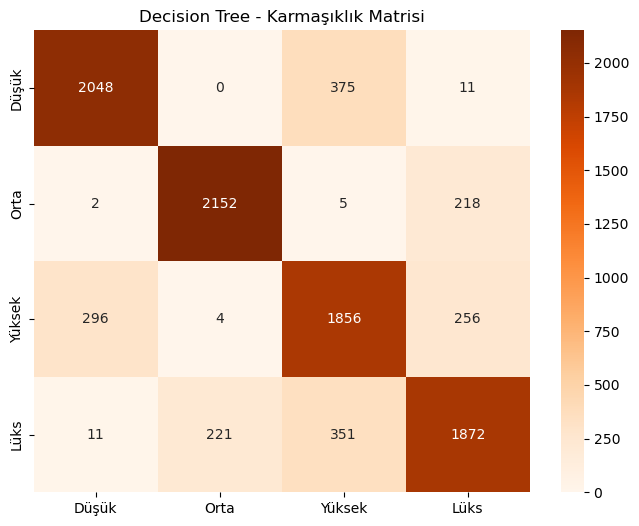

In [9]:
# GÖRSELLEŞTİRMELER 

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test_cls, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Düşük', 'Orta', 'Yüksek', 'Lüks'],
            yticklabels=['Düşük', 'Orta', 'Yüksek', 'Lüks'])
plt.title('Decision Tree - Karmaşıklık Matrisi')
plt.show()

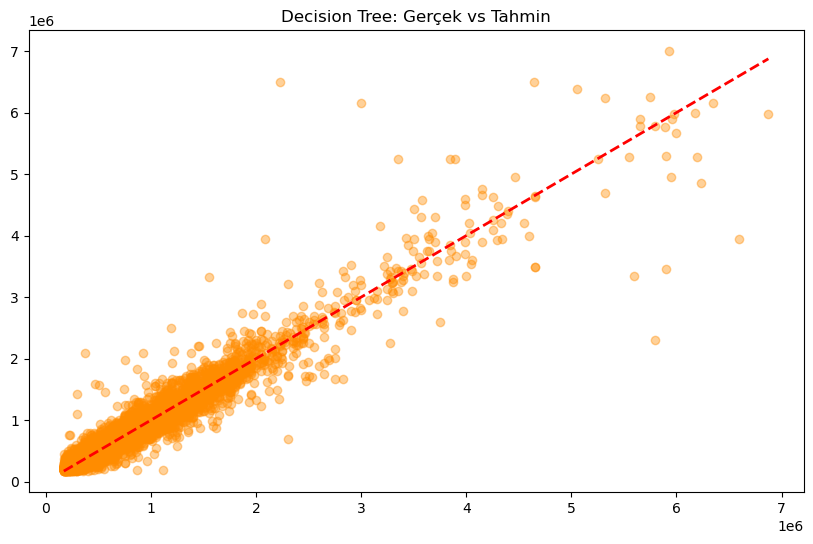

In [10]:
# Gerçek vs Tahmin Grafiği
plt.figure(figsize=(10,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color='darkorange')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Decision Tree: Gerçek vs Tahmin')
plt.show()

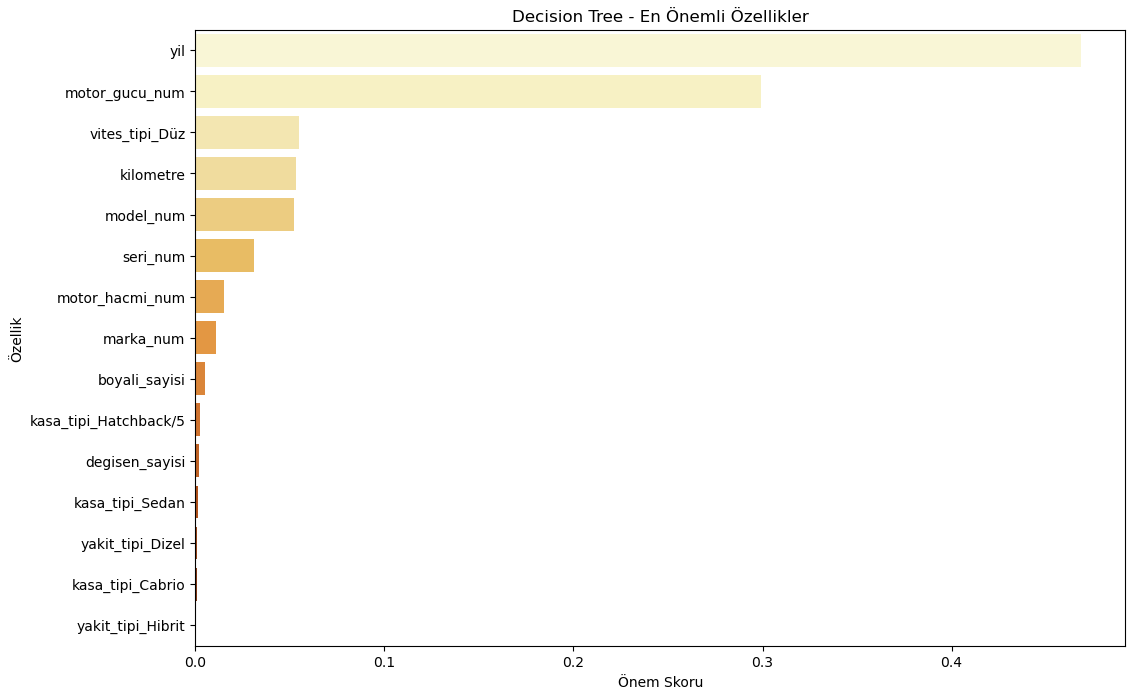

In [11]:
# Özellik Önem Sıralaması
importances = dt_reg.feature_importances_
feature_importance_df = pd.DataFrame({
    'Özellik': X.columns,
    'Önem Skoru': importances
}).sort_values(by='Önem Skoru', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x="Önem Skoru", y="Özellik", data=feature_importance_df.head(15), 
            palette="YlOrBr", hue="Özellik", legend=False)
plt.title('Decision Tree - En Önemli Özellikler')
plt.show()

In [12]:
# MODEL PAKETLEME VE KAYIT 
model_paketi = {
    'regresyon_modeli': dt_reg,
    'siniflandirma_modeli': dt_cls,
    'egitim_sutunlari': X.columns.tolist(),
    'alt_limit': alt_limit,
    'ust_limit': ust_limit
}
joblib.dump(model_paketi, "decision_tree.joblib")
print("✅ Decision Tree Modeli başarıyla kaydedildi.")

✅ Decision Tree Modeli başarıyla kaydedildi.


In [13]:
# ÖRNEK UYGULAMA 
def arac_fiyat_tahmin(model, arac_bilgisi, egitim_sutunlari):
    df_input = pd.DataFrame([arac_bilgisi])
    for col in egitim_sutunlari:
        if col not in df_input.columns:
            df_input[col] = 0
    df_input = df_input[egitim_sutunlari]
    return model.predict(df_input)[0]

yeni_arac = {
   "yil": 2021,
    "kilometre": 63000,
    "degisen_sayisi": 0,
    "boyali_sayisi": 0,
    "motor_hacmi_num": 1490,
    "motor_gucu_num": 125,
    "marka_num": 50,      # Toyota ID
    "seri_num": 144,      # Corolla ID
    "model_num": 940,     # 1.5 Dream ID
    "vites_tipi_Düz": 0,
    "vites_tipi_Otomatik": 1,
    "vites_tipi_Yarı Otomatik": 0,
    "yakit_tipi_Benzin": 1,
    "yakit_tipi_Dizel": 0,
    "yakit_tipi_Elektrik": 0,
    "yakit_tipi_Hibrit": 0,
    "yakit_tipi_LPG & Benzin": 0,
    "kasa_tipi_Cabrio": 0,
    "kasa_tipi_Coupe": 0,
    "kasa_tipi_Hatchback/3": 0,
    "kasa_tipi_Hatchback/5": 0,
    "kasa_tipi_MPV": 0,
    "kasa_tipi_Pick-up": 0,
    "kasa_tipi_Roadster": 0,
    "kasa_tipi_SUV": 0,
    "kasa_tipi_Sedan": 1,
    "kasa_tipi_Station wagon": 0
}

tahmin_fiyat = arac_fiyat_tahmin(dt_reg, yeni_arac, X.columns)
print(f"\nGirilen Aracın Tahmini Fiyatı: {tahmin_fiyat:,.0f} TL")


Girilen Aracın Tahmini Fiyatı: 1,430,000 TL
